In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_Считаем данные. 1000 объектов, 10 признаков и один таргет._

In [3]:
data = pd.read_csv('4 data.csv')
data.head()
#обозначим признаки и таргеты
X = data.drop(columns=['target'])
y = data['target']

_Проведем обучение через sklearn._

In [4]:
from sklearn.linear_model import LinearRegression
#создадим модель
model = LinearRegression()
#обучим модель
model.fit(X, y)
model.coef_, model.intercept_

(array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 np.float64(4.373157038707134))

#### **Класс для реализации градиентного спуска.**

In [5]:
class GradientDescentMse:
    #ИНИЦИАЛИЗАЦИЯ ОБЪЕКТА ДЛЯ ГРАДИЕНТНОГО СПУСКА -=-=-=-=-=-=-=-=-=-=-=-=-=-=
    def __init__(self, samples: pd.DataFrame, targets: pd.Series,
                 lr: float = 1e-3, thr: float = 1e-6,
                 copy: bool = True):
        #сохраним параметры как атрибуты объекта
        #в атрибут lr положим число lr и тд.
        self.lr = lr
        self.thr = thr
        #будет ли внутри объекта хранится копия x и y или ссылка на них?
        if copy:
            self.samples = samples.copy()
            self.targets = targets.copy()
        else:
            self.samples = samples
            self.targets = targets
        self.max_iter = 3_500 #максимальное число возможных итераций
    #ДОБАВЛЕНИЕ КОНСТАНТНОЙ ПЕРЕМЕННОЙ -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
    def add_constant_feature(self):
        #свободный коэффициент
        self.samples['inter'] = 1
        #создадим веса
        self.beta = np.ones(self.samples.shape[1])
    #ПОДСЧЕТ ПРЕДСКАЗАНИЯ -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
    def predict(self, samples):
        return samples.to_numpy() @ self.beta
    #РАСЧЕТ СРЕДНЕКВАДРАТИЧЕСКОЙ ОШИБКИ -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
    def calculate_mse_loss(self) -> float:
        #текущий ответ
        cur_ans = self.predict(self.samples) #вектор
        #ошибка по каждому объекту
        errors = cur_ans - self.targets.to_numpy() #вектор
        #среднеквадратическая ошибка
        mse = (errors**2).mean()
        return mse
    #ПОДСЧЕТ ВЕКТОРА ГРАДИЕНТА -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
    def calculate_gradient(self) -> np.ndarray:
        #текущий ответ
        cur_ans = self.predict(self.samples) #вектор
        #ошибка по каждому объекту
        errors = cur_ans - self.targets.to_numpy() #одномерный массив
        #сделаем ошибку вектором столбцом
        errors_vect = errors[:, None]
        #производная по каждому объекту и каждому признаку
        grads = self.samples.to_numpy() * errors_vect #матрица
        #среднее значения производной для признаков
        grads_vector = 2 * grads.mean(axis=0) #вектор
        return grads_vector
    #ОБНОВЛЕНИЕ ВЕСОВ МОДЕЛИ -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
    def iteration(self):
        #вычислим градиент с помощью прошлой функции
        grads = self.calculate_gradient()
        #сделаем шаг в противоположную сторону
        self.beta = self.beta - (self.lr * grads)
    #ОБУЧЕНИЕ -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
    def learn(self):
        #зададим атрибуты для обучения
        self.iter_loss_dict = {} #словарь для отслеживания ошибки
        self.iter_cnt = 0 #подсчет итераций
        #добавим колонку единиц, если это еще не сделали
        if 'inter' not in self.samples.columns:
            self.add_constant_feature()
        #если колонка была добавлена, значит обучение вызвали повторно
        else:
            #при повторном обучение, сбросим веса
            self.beta = np.ones(self.samples.shape[1])
        #начальная ошибка
        prev_mse = self.calculate_mse_loss()
        #повторяем цикл, пока не сработает критерий остановки
        while True:
            #сделаем один шаг градиентного спуска
            self.iteration()
            #вычислим новую ошибку
            new_mse = self.calculate_mse_loss()
            #засчитаем эту итерацию
            self.iter_cnt += 1
            #сохраним результат итерации
            self.iter_loss_dict[self.iter_cnt] = new_mse
            #проверим критерий остановки
            if abs(prev_mse - new_mse) < self.thr or \
                self.iter_cnt >= self.max_iter:
                break
            #запишем новую ошибку как текущую
            prev_mse = new_mse
        #сохраним последнее значение ошибки
        self.last_mse = prev_mse
        #вернем полученные веса
        return self.beta

#### **Построим графики для обучения модели с разными lr и thr.**

_Зададим функцию для создания графика с нашими настройками. Укажем в какой части полотна ему нужно рисовать. Передадим ему значения lr и thr, чтобы задать подпись для графика._

In [32]:
def holst(ax, dicter, lr, thr):
    ax.set_ylabel('MSE', color='#fbceb1', size=40)
    ax.set_xlabel('iteration', color='#8ccb5e', size=15)
    ax.plot(dicter.keys(), dicter.values(), color='#79553d')
    ax.scatter(list(dicter.keys())[-1], list(dicter.values())[-1],
                color='#cd5c5c',
                s=100,
                label=f'Последнее значение ошибки:{list(dicter.values())[-1]:.5f}')
    ax.set_title(f"lr={lr}, thr={thr}", color='#cd5c5c')
    ax.legend()


_Обучим модель с правильными параметрами._

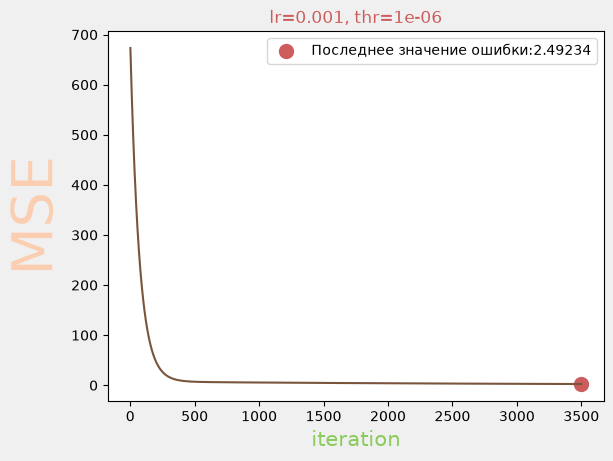

In [33]:
#создадим новую фигуру и поделим её на кусочки
fig = plt.figure(facecolor='#f0f0f0')
ax = fig.add_subplot(1, 1, 1)
#создаем объект
GD = GradientDescentMse(X, y)
#обучаем объект
GD.learn()
#отобразим изменение его ошибки
holst(ax, GD.iter_loss_dict, GD.lr, GD.thr)

_Поставим слишком маленькое значение lr._

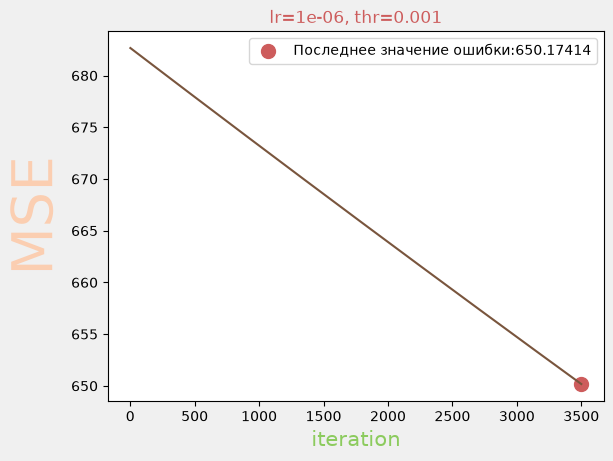

In [34]:
#создадим новую фигуру и поделим её на кусочки
fig = plt.figure(facecolor='#f0f0f0')
ax = fig.add_subplot(1, 1, 1)
#обучим объект снова
GD.lr = 1e-6
GD.thr = 1e-3
GD.learn()
#отобразим график
holst(ax, GD.iter_loss_dict, GD.lr, GD.thr)

_Поставим слишком большое значение lr._

C:\Users\user\Desktop\PycharmProjects\new\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\user\AppData\Local\Temp\ipykernel_9320\1244453840.py:80: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_mse - new_mse) < self.thr or \
C:\Users\user\AppData\Local\Temp\ipykernel_9320\1244453840.py:34: RuntimeWarning: overflow encountered in square
  mse = (errors**2).mean()


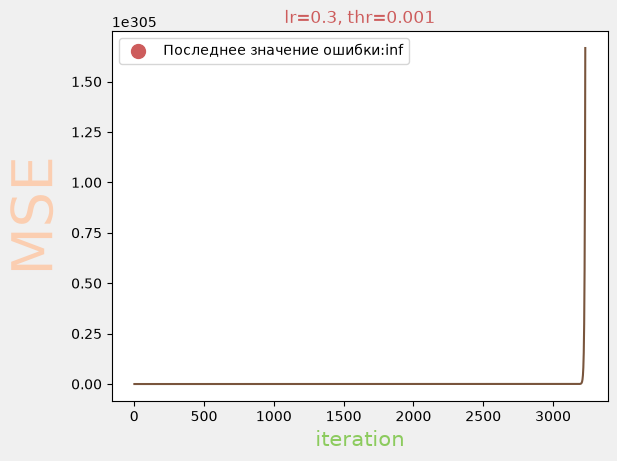

In [35]:
#создадим новую фигуру и поделим её на кусочки
fig = plt.figure(facecolor='#f0f0f0')
ax = fig.add_subplot(1, 1, 1)
#обучим объект снова
GD.lr = 0.3
GD.learn()
holst(ax, GD.iter_loss_dict, GD.lr, GD.thr)

#### **Создадим сетку графиков с разными комбинациями lr и thr.**

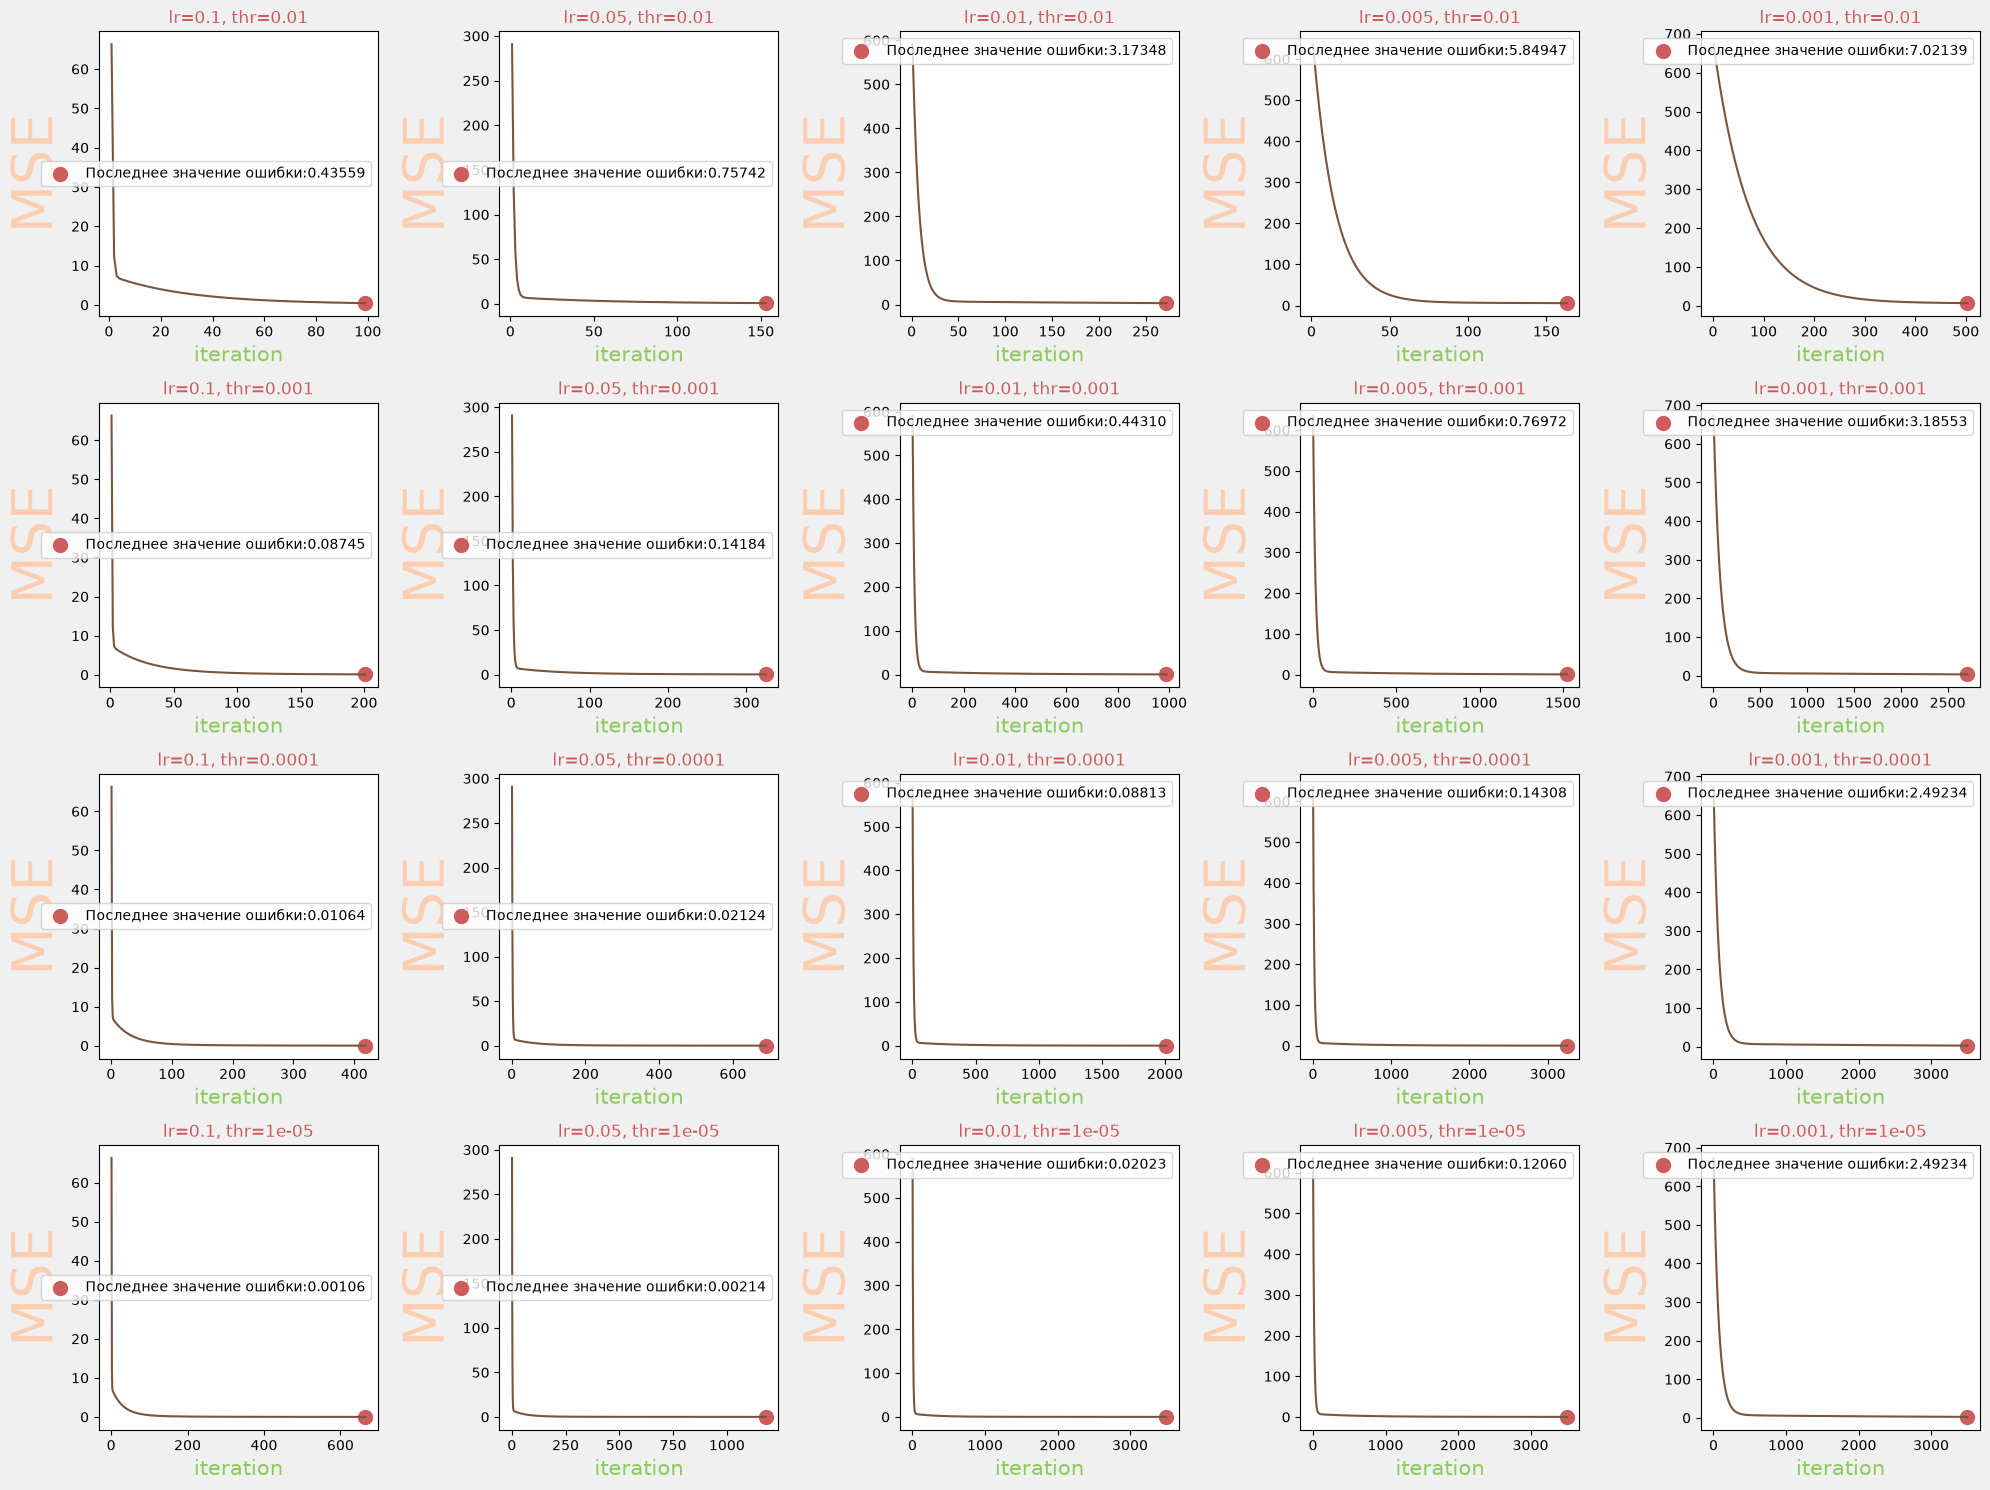

Лучшая комбинация скорости и критерия проверки это: 
lr = 0.1
thr = 1e-05


In [39]:
lr_val = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3]
thr_val = [1e-2, 1e-3, 1e-4, 1e-5]
#всё будет изображено на одном графике
fig = plt.figure(figsize=(20, 15), facecolor='#f0f0f0')
#будем считать в какой части графика рисовать
num = 1
#переберем все комбинации значений
#чтобы найти лучшие
best_lr_thr = None
min_mse = float('inf')
for thr_cur in thr_val:
    for lr_cur in lr_val:
        #создаем новый объект
        GD = GradientDescentMse(X, y, lr_cur, thr_cur)
        #обучим его
        GD.learn()
        #проверим была ли ошибка минимальной
        if GD.last_mse < min_mse:
            min_mse = GD.last_mse
            best_lr_thr = [GD.lr, GD.thr]
        #выделим для него место
        ax = fig.add_subplot(4, 5, num)
        #изобразим его
        holst(ax, GD.iter_loss_dict, GD.lr, GD.thr)
        num += 1
plt.tight_layout()
plt.show()
print(f'Лучшая комбинация скорости и критерия проверки это: \nlr = {best_lr_thr[0]}\nthr = {best_lr_thr[1]}')